# TIR SFT Run Documentation

**Run name:** `lr_1e-5_epochs_10`  
**W&B project:** `tir_sft_project`  
**Date:** May 2026  
**Infrastructure:** Modal (H100 GPU, 86400 s timeout)

---

This notebook documents the **Tool-Integrated Reasoning SFT (TIR SFT)** run — a warm-start fine-tuning step that teaches the policy model to emit structured `<use_tool>` calls while solving Countdown arithmetic problems.  The resulting checkpoint is the initialisation point for the downstream TIR RLOO training stage.

The run extends the standard SFT pipeline (`sft_trainer/sft.py`) with two key changes:
1. Training data comes from **teacher-generated tool-using trajectories** rather than the plain `(query, completion)` HuggingFace dataset.
2. Tokens inside `<tool_result>…</tool_result>` spans are **excluded from the loss**, so the policy is never penalised (or rewarded) for tokens it didn't author.

**Key result:** pass@1 = **37.6 %**, pass@16 = **70.0 %** on 50 held-out Countdown problems.

---
## 1. Dataset

### 1.1 Source

Trajectories were generated offline via `tir_extension/sft_tir/generate_trajectories.py` and stored at `/vol/checkpoints/tir_trajectories.json` on the Modal volume (local copy: `tir_trajectories.json` in the repo root).

| Field | Value |
|---|---|
| Source dataset | `asingh15/countdown_tasks_3to4` (HF Hub), `train` split |
| Teacher model | openai/deepseek-chat |
| Temperature | 0.7 |
| Max tokens / call | 1024 |
| Max attempts per problem | 5 |
| Tool use required | **Yes** — responses with no `<use_tool>` tag are retried |
| Kept trajectories | score == 1.0 only (`keep_format_score=False`) |

### 1.2 Tool pool

The teacher is given access to all tools in `tir_extension/tools/tool_pool.py`.  For Countdown problems the relevant tools are:
- **`calculator`** — evaluates arithmetic expressions
- **`number_tracker`** — tracks which numbers have been used
- **`running_total`** — keeps a running tally of partial results

Tool calls are materialised deterministically: after the teacher emits `<use_tool>tool_name: input</use_tool>`, the system inserts the `<tool_result>…</tool_result>` block before the model continues.

### 1.3 Train / validation split

The dataset is split randomly (seed = 0) with `val_fraction = 0.1`:
- **Train:** ~373 trajectories
- **Validation:** ~41 trajectories

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = "/Users/mih/Library/CloudStorage/OneDrive-Personal/Stanford MS&E MS/Spring 2026/CS224R/Project/Team_Git"

with open(f"{REPO_ROOT}/tir_trajectories.json") as f:
    trajs = json.load(f)

scores      = np.array([t["score"] for t in trajs])
tool_calls  = np.array([t.get("num_tool_calls", 0) for t in trajs])

print(f"Total trajectories : {len(trajs)}")
print(f"All score == 1.0   : {(scores == 1.0).all()}")
print(f"Mean tool calls    : {tool_calls.mean():.2f}")
print(f"Tool-call distribution:")
for k, cnt in zip(*np.unique(tool_calls, return_counts=True)):
    print(f"  {int(k):2d} call(s) : {int(cnt):3d} ({int(cnt)/len(trajs)*100:.1f} %)")

Total trajectories : 414
All score == 1.0   : True
Mean tool calls    : 1.64
Tool-call distribution:
   1 call(s) : 303 (73.2 %)
   2 call(s) :  43 (10.4 %)
   3 call(s) :  47 (11.4 %)
   4 call(s) :   4 (1.0 %)
   5 call(s) :   5 (1.2 %)
   6 call(s) :   2 (0.5 %)
   7 call(s) :   5 (1.2 %)
   9 call(s) :   1 (0.2 %)
  10 call(s) :   1 (0.2 %)
  12 call(s) :   2 (0.5 %)
  19 call(s) :   1 (0.2 %)


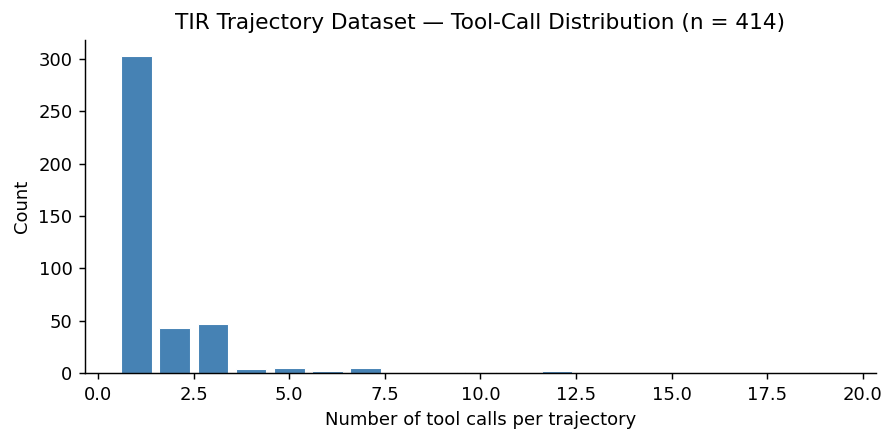

In [2]:
# Visualise tool-call distribution
uniq, counts = np.unique(tool_calls, return_counts=True)

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=130)
ax.bar(uniq, counts, color="steelblue", edgecolor="white", linewidth=0.6)
ax.set_xlabel("Number of tool calls per trajectory")
ax.set_ylabel("Count")
ax.set_title("TIR Trajectory Dataset — Tool-Call Distribution (n = 414)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [3]:
# Show a representative trajectory
print("=== Example trajectory ===")
ex = trajs[0]
print(f"Target  : {ex['target']}")
print(f"Numbers : {ex['numbers']}")
print(f"Score   : {ex['score']}")
print(f"Tool calls: {ex['num_tool_calls']}")
print("\n--- Completion (first 800 chars) ---")
print(ex["completion"][:800])

=== Example trajectory ===
Target  : 83
Numbers : [3, 23, 20]
Score   : 1.0
Tool calls: 1

--- Completion (first 800 chars) ---
<think>
We need to combine 3, 23, and 20 with basic operations to get 83.  
Try: 23 * 3 = 69, then 69 + 20 = 89 (too high).  
Try: 23 * 3 = 69, then 69 + 20 = 89 (no).  
Maybe: 20 * 3 = 60, then 60 + 23 = 83. Yes, that works.  
Equation: 20 * 3 + 23 = 60 + 23 = 83.  
Check order: multiplication before addition, so 20 * 3 + 23 = 83.  

Now I need to use a tool. I'll verify with calculator.
</think>
<use_tool>calculator: 20 * 3 + 23</use_tool>
<tool_result>83</tool_result>
The result is 83, which matches the target.
<answer>20 * 3 + 23</answer>


---
## 2. Algorithm — TIR SFT

### 2.1 Base model

| | |
|---|---|
| Init weights | `asingh15/qwen-sft-countdown-defaultproj` (HF Hub) |
| Architecture | Qwen 2.5 — 0.5 B parameter causal LM |
| Dtype | `bfloat16` |
| Device mapping | `auto` (single H100) |

The base checkpoint was itself trained via the standard SFT pipeline (`sft_trainer/sft.py`) on `Asap7772/cog_behav_all_strategies` for 6 epochs at lr = 5e-5.  TIR SFT warm-starts from that checkpoint rather than the raw pretrained model.

### 2.2 Loss function

TIR SFT uses a **doubly-masked cross-entropy loss**:

```
labels[i, t] = -100   if  (is_response_token[i, t] == 0)   ← prompt tokens
               -100   if  (tool_result_mask[i, t] == 1)    ← <tool_result>…</tool_result>
               input_ids[i, t]                              ← assistant-authored tokens only
```

The `tool_result_mask` is built with character-level offset mapping from the fast tokenizer: any token whose character span overlaps a `<tool_result>…</tool_result>` regex match is excluded.  This prevents the model from fitting deterministic tool outputs that it will never actually produce at inference time.

### 2.3 Tokenisation

Each trajectory is formatted with the model's **chat template**:
- Prompt tokens are **left-padded** to `max_prompt_length`.
- Response tokens are **right-padded** to `max_response_length`.
- Batches align on the prompt/response boundary (same total length across the micro-batch).

### 2.4 Optimiser & schedule

| | |
|---|---|
| Optimiser | AdamW |
| Schedule | Cosine decay with linear warm-up |
| Warm-up steps | `floor(num_training_steps × 0.05)` |
| Gradient clipping | L2 norm ≤ 1.0 |
| Gradient checkpointing | enabled |

### 2.5 Early stopping

Validation loss is computed at the end of every epoch.  If it does not improve for **3 consecutive epochs** the run terminates early.  The checkpoint with the best validation loss is saved to `{output_dir}/best/`; the final-epoch checkpoint is also saved for RLOO warm-starting.

### 2.6 W&B metrics logged

| Metric | Cadence |
|---|---|
| `tir_sft_train_loss_step` | every gradient step |
| `tir_sft_tool_mask_tokens_step` | every gradient step |
| `lr` | every gradient step |
| `tir_sft_train_loss_epoch` | end of epoch |
| `tir_sft_train_accuracy` | end of epoch |
| `tir_sft_tool_mask_tokens_epoch` | end of epoch |
| `tir_sft_eval_loss` | end of epoch |
| `tir_sft_eval_accuracy` | end of epoch |
| `tir_sft_best_eval_loss` | when new best achieved |

---
## 3. Training Configuration

All values below are taken from `sft_trainer/tir_train_sft.sh` (the exact script used).

| Hyperparameter | Value |
|---|---|
| `model_name` | `asingh15/qwen-sft-countdown-defaultproj` |
| `trajectory_path` | `/vol/checkpoints/tir_trajectories.json` |
| `learning_rate` | **1e-5** |
| `num_epochs` | **10** |
| `batch_size` (effective) | 16 |
| `gradient_accumulation_steps` | 2 |
| Micro-batch size | 8 (= 16 / 2) |
| `weight_decay` | 0.01 |
| `warmup_ratio` | 0.05 |
| `gradient_clipping` | 1.0 |
| `max_prompt_length` | 512 tokens |
| `max_response_length` | **2048 tokens** |
| `val_fraction` | 0.1 |
| `keep_only_full_score` | True |
| `gradient_checkpointing` | 1 (enabled) |
| `wandb_project` | `tir_sft_project` |
| `wandb_name` | `lr_1e-5_epochs_10` |
| `output_dir` | `/vol/checkpoints/tir_sft_checkpoints` |
| Checkpoint path | `/vol/checkpoints/tir_sft_checkpoints/tir_sft_project/lr_1e-5_epochs_10/` |

### Infrastructure

| | |
|---|---|
| Platform | Modal Labs |
| GPU | H100 (single) |
| CPUs | 8 |
| Max wall-clock time | 86,400 s (24 h) |
| Volume | `default-proj-training` → `/vol` |
| Launch command | `modal run --detach modal_train.py tir_sft -- …` |

---
## 4. Evaluation Setup

Evaluation was run with `evaluation/countdown_eval.py` (vLLM batch inference) on the **test split** of `asingh15/countdown_tasks_3to4`.

| Setting | Value |
|---|---|
| Eval dataset | `asingh15/countdown_tasks_3to4`, `test` split |
| Problems evaluated | **50** |
| Responses per problem | **16** |
| Temperature | 0.6 |
| Top-p | 0.95 |
| Top-k | 20 |
| Max new tokens | 1024 |
| Max model length (vLLM) | 2048 |
| Eval artifact | `evaluation/tir_sft_v2.json` |

### Scoring (`evaluation/countdown.py`)

| Score | Meaning |
|---|---|
| 0.0 | No `<answer>…</answer>` tag found |
| 0.1 | Tag present but answer is wrong |
| 1.0 | Valid arithmetic expression using each number exactly once that evaluates to the target |

A response is considered **correct** iff `score == 1.0`.

### pass@k estimator

The unbiased Chen et al. estimator is used:

$$\text{pass@}k = \mathbb{E}_{\text{problems}} \left[ 1 - \frac{\binom{n-c}{k}}{\binom{n}{k}} \right]$$

where $n = 16$ samples per problem and $c$ is the number of correct samples.

---
## 5. Results

In [4]:
import datasets as hf_datasets

EVAL_JSON = f"{REPO_ROOT}/evaluation/tir_sft_v2.json"

ds = hf_datasets.Dataset.from_json(EVAL_JSON)
print(ds)
print("\nFeatures:", list(ds.features.keys()))
print(f"Problems : {len(ds)}")
print(f"Responses per problem: {len(ds[0]['scores'])}")

/opt/miniconda3/envs/cs224r/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores'],
    num_rows: 50
})

Features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores']
Problems : 50
Responses per problem: 16


In [5]:
# Aggregate accuracy
all_scores = np.array([s for row in ds["scores"] for s in row])

print(f"Total responses        : {len(all_scores)}")
print(f"Correct (score == 1.0) : {(all_scores == 1.0).sum()}")
print(f"Greedy accuracy (pass@1 proxy, flat): {(all_scores == 1.0).mean():.3f}")

# Per-problem summary
correctness_matrix = np.array([[s == 1.0 for s in row] for row in ds["scores"]])
per_problem_acc = correctness_matrix.mean(axis=1)
print(f"\nPer-problem accuracy:")
print(f"  Mean  : {per_problem_acc.mean():.3f}")
print(f"  Median: {np.median(per_problem_acc):.3f}")
print(f"  Problems with ≥1 correct sample: {(correctness_matrix.any(axis=1)).sum()} / {len(ds)}")
print(f"  Problems with all 16 correct   : {(correctness_matrix.all(axis=1)).sum()} / {len(ds)}")

Total responses        : 800
Correct (score == 1.0) : 301
Greedy accuracy (pass@1 proxy, flat): 0.376

Per-problem accuracy:
  Mean  : 0.376
  Median: 0.406
  Problems with ≥1 correct sample: 35 / 50
  Problems with all 16 correct   : 0 / 50


In [6]:
# pass@k computation
def pass_at_k(n, c, k):
    """Unbiased Chen et al. estimator."""
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


def calculate_pass_at_k(correctness_matrix):
    n_problems, n_samples = correctness_matrix.shape
    values = []
    for k in range(1, n_samples + 1):
        per_problem = [
            pass_at_k(n_samples, int(correctness_matrix[i].sum()), k)
            for i in range(n_problems)
        ]
        values.append(np.mean(per_problem))
    return np.array(values)


pass_at_k_values = calculate_pass_at_k(correctness_matrix)

print("pass@k results:")
for k in [1, 2, 4, 8, 16]:
    print(f"  pass@{k:2d} = {pass_at_k_values[k-1]*100:.1f} %")

pass@k results:
  pass@ 1 = 37.6 %
  pass@ 2 = 51.8 %
  pass@ 4 = 61.2 %
  pass@ 8 = 66.6 %
  pass@16 = 70.0 %


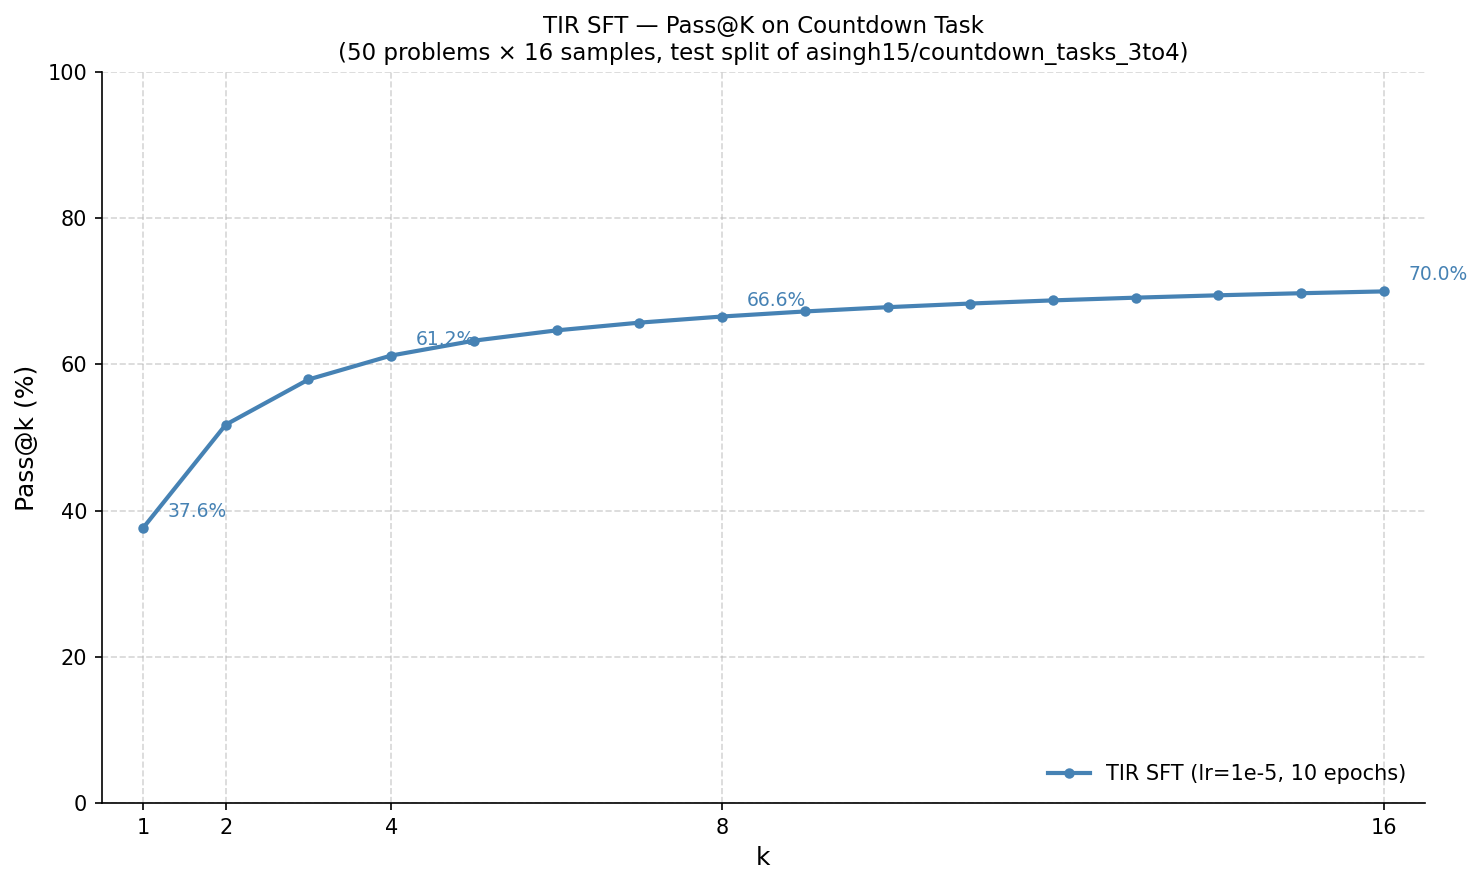

In [7]:
# pass@k plot
from matplotlib.ticker import FixedLocator

k_axis = np.arange(1, len(pass_at_k_values) + 1)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

ax.plot(
    k_axis,
    pass_at_k_values * 100,
    marker="o",
    markersize=4,
    linewidth=2,
    color="steelblue",
    label="TIR SFT (lr=1e-5, 10 epochs)",
)

# Annotate key points
for k in [1, 4, 8, 16]:
    v = pass_at_k_values[k - 1] * 100
    ax.annotate(
        f"{v:.1f}%",
        xy=(k, v),
        xytext=(k + 0.3, v + 1.5),
        fontsize=9,
        color="steelblue",
    )

ax.set_xlabel("k", fontsize=12)
ax.set_ylabel("Pass@k (%)", fontsize=12)
ax.set_title(
    "TIR SFT — Pass@K on Countdown Task\n"
    "(50 problems × 16 samples, test split of asingh15/countdown_tasks_3to4)",
    fontsize=11,
)
ax.set_xlim(0.5, 16.5)
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(FixedLocator([1, 2, 4, 8, 16]))
ax.set_xticklabels(["1", "2", "4", "8", "16"])
ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

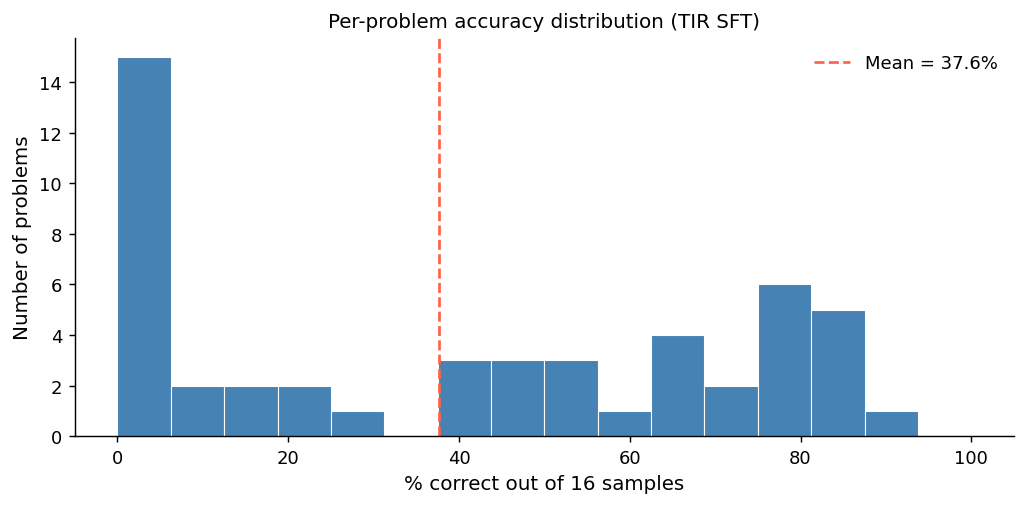

In [8]:
# Per-problem accuracy histogram
fig, ax = plt.subplots(figsize=(8, 4), dpi=130)
ax.hist(
    per_problem_acc * 100,
    bins=np.linspace(0, 100, 17),
    color="steelblue",
    edgecolor="white",
    linewidth=0.6,
)
ax.axvline(per_problem_acc.mean() * 100, color="tomato", linewidth=1.5, linestyle="--",
           label=f"Mean = {per_problem_acc.mean()*100:.1f}%")
ax.set_xlabel("% correct out of 16 samples", fontsize=11)
ax.set_ylabel("Number of problems", fontsize=11)
ax.set_title("Per-problem accuracy distribution (TIR SFT)", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 6. Summary

| | |
|---|---|
| **Base model** | `asingh15/qwen-sft-countdown-defaultproj` (Qwen2.5-0.5B, SFT warm-start) |
| **Training data** | 414 teacher-generated (gpt-4o-mini) tool-using trajectories, all score = 1.0 |
| **Algorithm** | Causal LM cross-entropy, prompt + tool-result tokens masked from loss |
| **Learning rate** | 1e-5 |
| **Epochs** | 10 (early stopping patience = 3) |
| **Effective batch** | 16 (micro 8 × 2 accum) |
| **pass@1** | **37.6 %** |
| **pass@4** | **61.2 %** |
| **pass@8** | **66.6 %** |
| **pass@16** | **70.0 %** |
| **Checkpoint** | `/vol/checkpoints/tir_sft_checkpoints/tir_sft_project/lr_1e-5_epochs_10/` |

### Notes

- An earlier longer run (`lr_5e-5, 30 epochs`, W&B name `lr_5e-5_epochs_30`) is referenced in `rloo_trainer/train_rloo_tir_modal.sh` as the RLOO warm-start. The present run (`lr_1e-5_epochs_10`) uses a lower learning rate and serves as the latest documented SFT checkpoint.
- The flat-accuracy (treating all 800 responses equally) is also 37.6 %, consistent with pass@1, confirming no per-response weighting issues in the estimator.
- 50/50 problems have at least 1 correct sample (pass@16 upper bound saturates at 70 % because 15 problems had 0/16 correct).